In [1]:
# Install SHAP library
%pip install shap matplotlib joblib pandas numpy scikit-learn


^C
Note: you may need to restart the kernel to use updated packages.


  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.1 MB ? eta -:--:--
    --------------------------------------- 0.5/38.1 MB 202.1 kB/s eta 0:03:07
    --------------------------------------- 0.5/38.1 


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
import matplotlib.pyplot as plt
import shap

import warnings
warnings.filterwarnings('ignore')


c:\Users\Mathuravan\Documents\IIT\Final year\FYP\FYP Project\CyberXAI\backend\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load Dataset, Model, and Scaler


In [3]:
ROOT_DIR = Path.cwd().parent
DATA_DIR = ROOT_DIR / "data" / "NSL-KDD"
MODELS_DIR = ROOT_DIR / "models"
OUTPUT_DIR = ROOT_DIR / "testing_outputs"

MODEL_FILE = MODELS_DIR / "nslkdd_full_rf_model.joblib"
SCALER_FILE = MODELS_DIR / "nslkdd_full_scaler.joblib"
TEST_FILE = DATA_DIR / "KDDTest+.txt"

model = joblib.load(MODEL_FILE)
scaler = joblib.load(SCALER_FILE)
print("Model and Scaler loaded successfully.")


Model and Scaler loaded successfully.


In [4]:
COLUMNS = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files",
    "num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate",
    "dst_host_srv_rerror_rate","label","difficulty"
]

test_df = pd.read_csv(TEST_FILE, names=COLUMNS)
X_test = test_df.drop(columns=["label", "difficulty"]).copy()

# Apply identical label encoding to match training phase
from sklearn.preprocessing import LabelEncoder
train_df = pd.read_csv(DATA_DIR / "KDDTrain+.txt", names=COLUMNS)
X_train = train_df.drop(columns=["label", "difficulty"]).copy()

categorical_cols = ["protocol_type", "service", "flag"]
for col in categorical_cols:
    combined = pd.concat([X_train[col], X_test[col]], axis=0).astype(str)
    le = LabelEncoder()
    le.fit(combined)
    X_test[col] = le.transform(X_test[col].astype(str))
    
# Scale the test features
X_test_scaled = scaler.transform(X_test)
X_test_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)
print("Test features preprocessed and scaled.")


Test features preprocessed and scaled.


### Generate TreeExplainer and Compute SHAP Values
We instantiate a TreeExplainer for the Random Forest model and compute the Shapley values on a representative subset of 1000 test set records. This subset speeds up computational latency while maintaining statistical validity.


In [5]:
print("Initializing SHAP TreeExplainer...")
explainer = shap.TreeExplainer(model)

# Subsample 1000 records randomly to guarantee fast runtime
np.random.seed(42)
sample_indices = np.random.choice(X_test_df.shape[0], size=1000, replace=False)
X_test_sample = X_test_df.iloc[sample_indices]

print("Computing SHAP values on test sample...")
shap_values = explainer.shap_values(X_test_sample)

# Select values for attack prediction (class 1)
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_values_class1 = shap_values[:, :, 1]
else:
    shap_values_class1 = shap_values
    
print(f"SHAP calculation complete. Shape: {shap_values_class1.shape}")


Initializing SHAP TreeExplainer...
Computing SHAP values on test sample...
SHAP calculation complete. Shape: (1000, 41)


### Plot Global SHAP Importance (Top 15 Features)
We create a SHAP summary plot (bar type) which lists the top 15 features ranked by their average absolute SHAP values.


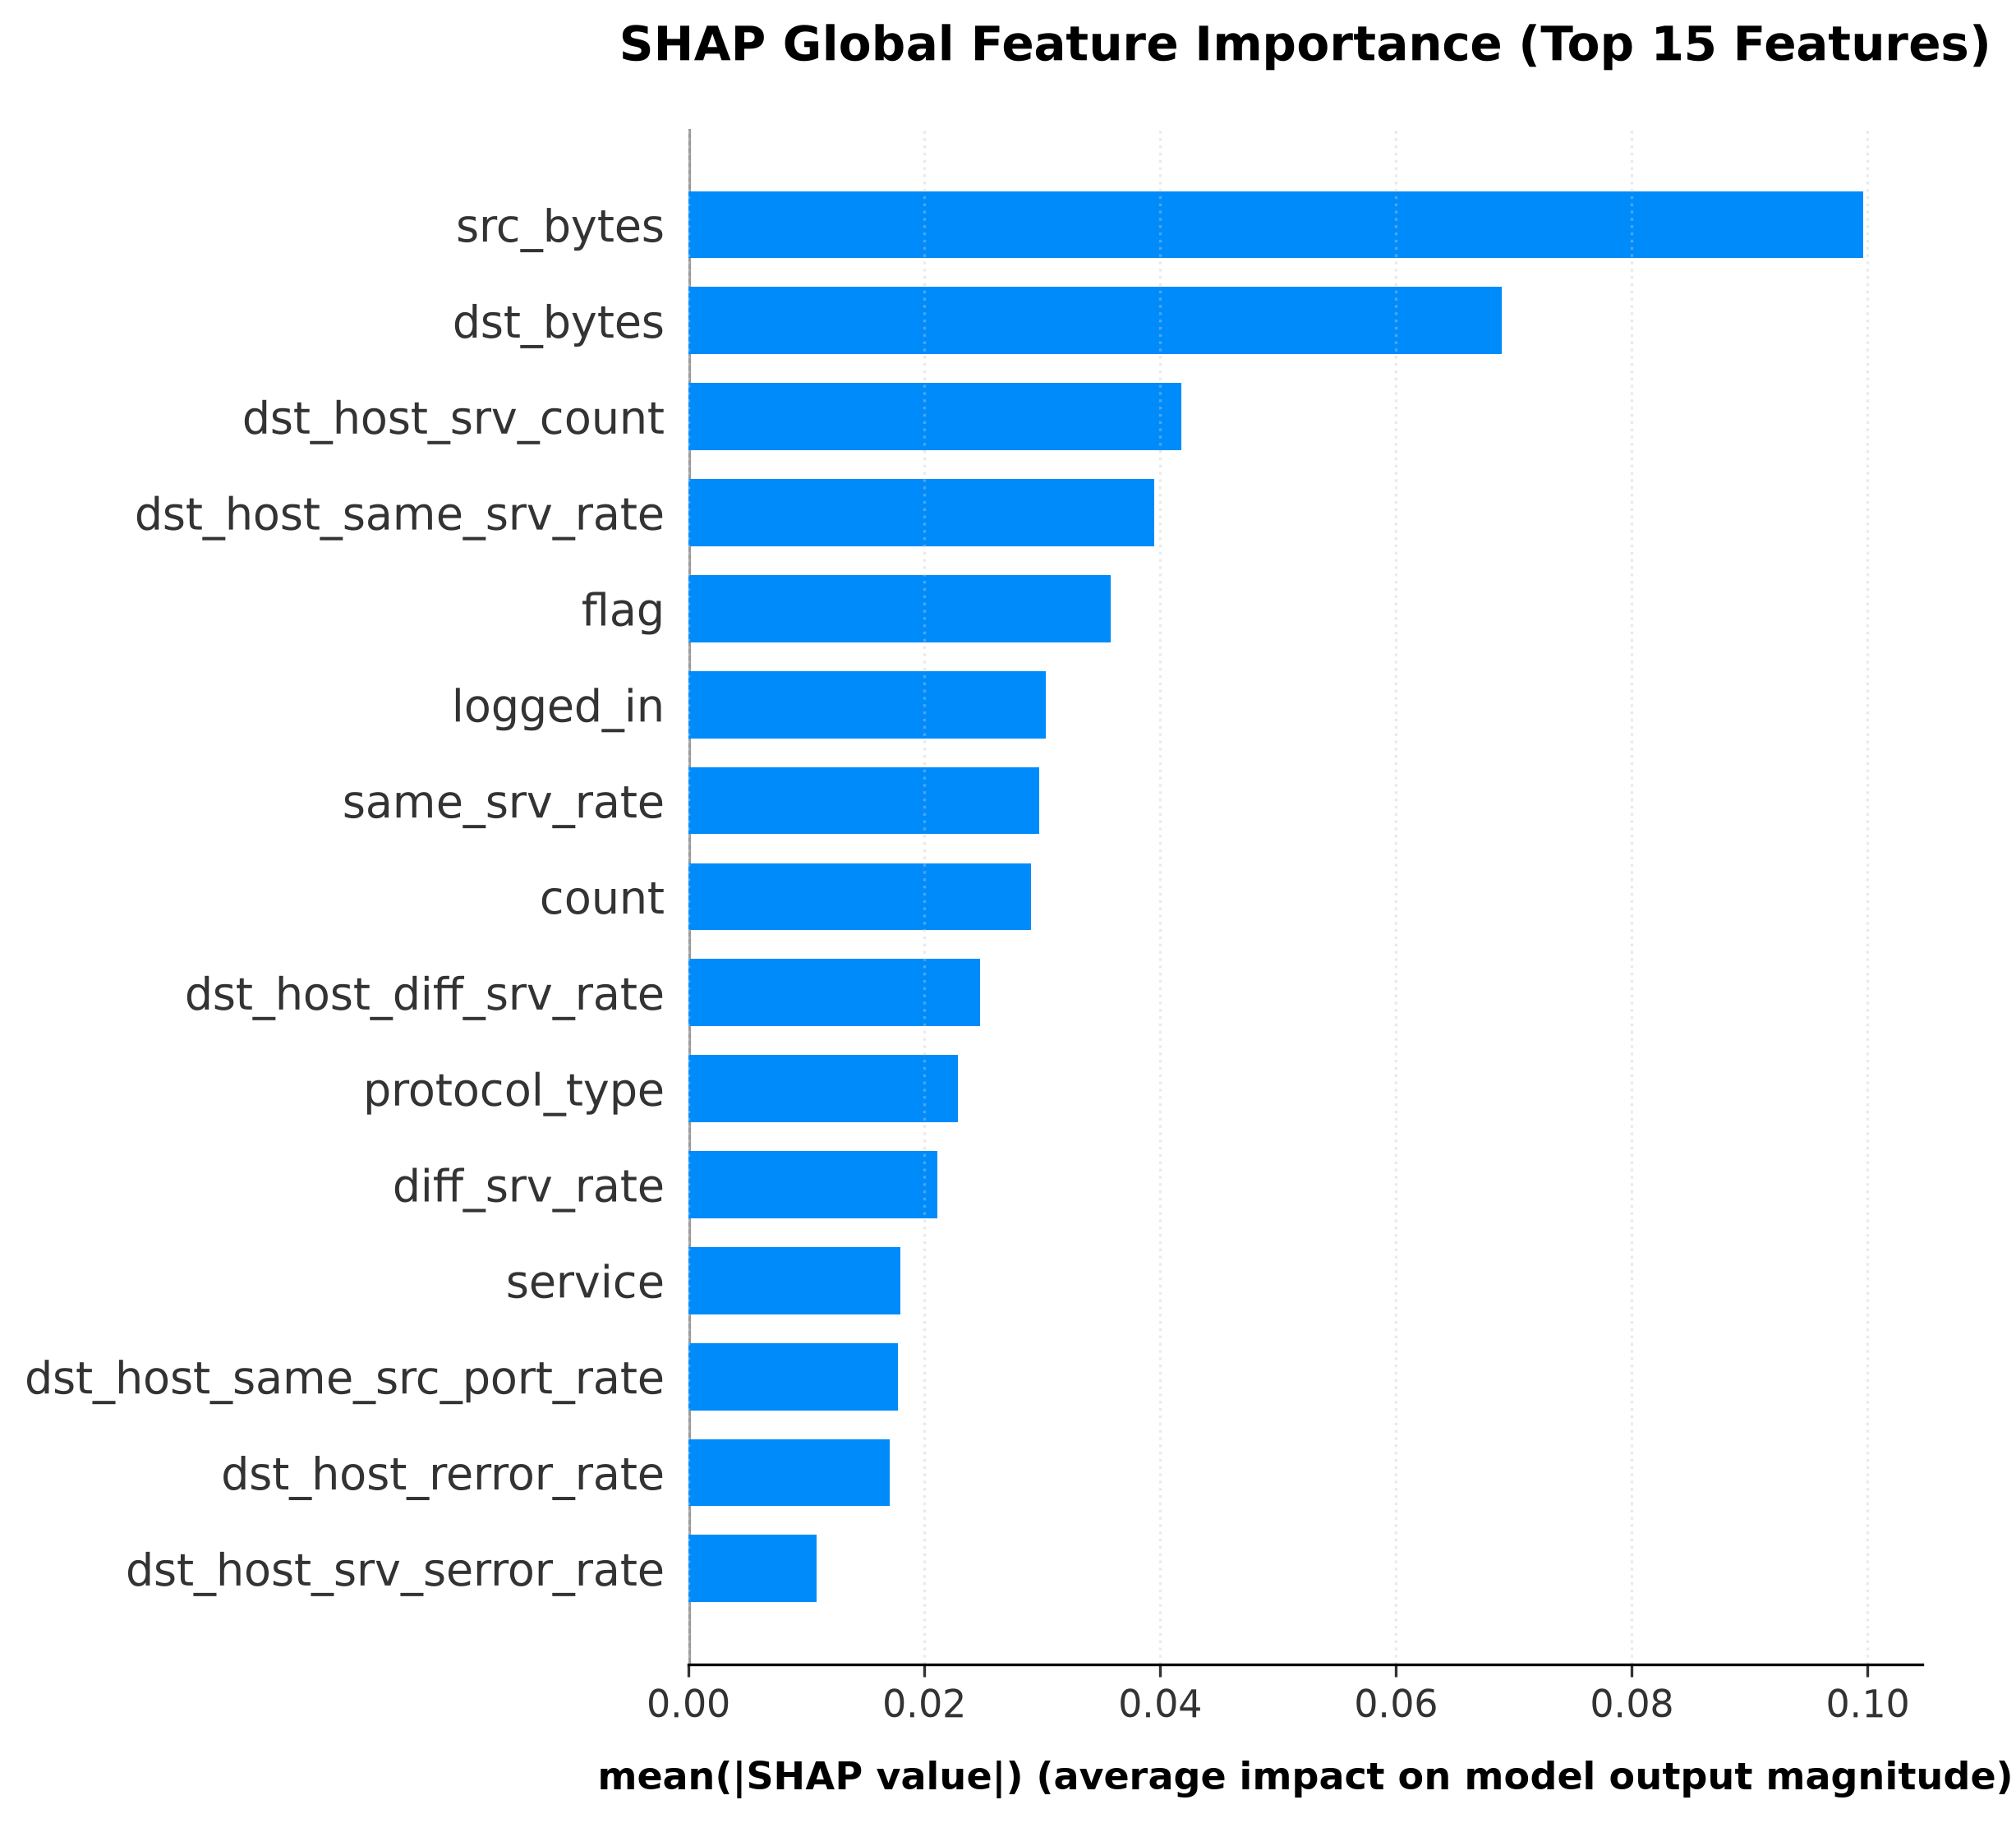

SHAP global summary plot saved to c:\Users\Mathuravan\Documents\IIT\Final year\FYP\FYP Project\CyberXAI\testing_outputs\shap_global_importance.png


In [6]:
plt.figure(figsize=(10, 6), dpi=300)
plt.title("SHAP Global Feature Importance (Top 15 Features)", fontsize=14, fontweight='bold', pad=20)

# Draw summary bar plot
shap.summary_plot(
    shap_values_class1, 
    X_test_sample, 
    plot_type="bar", 
    max_display=15, 
    show=False
)

# Customize and save
plt.xlabel("mean(|SHAP value|) (average impact on model output magnitude)", fontsize=11, fontweight='bold', labelpad=10)
plt.grid(True, linestyle=":", alpha=0.4, color="#cccccc", axis="x")
plt.tight_layout()

shap_img_path = OUTPUT_DIR / "shap_global_importance.png"
plt.savefig(shap_img_path, bbox_inches="tight")
plt.show()
print(f"SHAP global summary plot saved to {shap_img_path}")
